## Переход к анализу нового таргета

Общий обзор и базовые характеристики датасета уже были рассмотрены ранее в рамках этапа `cp1`. Поэтому в данном ноутбуке не будем повторять полный первичный анализ и сосредоточимся именно на новой целевой переменной.

Далее рассматривается таргет `Money Laundering Risk Score`: его распределение, основные статистики и связь с признаками, которые могут быть полезны для последующего моделирования.

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [12]:
DATA_DIR = Path("../data/processed")
RANDOM_STATE = 42
train_df = pd.read_csv(DATA_DIR / "train.csv")
valid_df = pd.read_csv(DATA_DIR / "valid.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

In [3]:
df = pd.concat([train_df, valid_df, test_df], axis=0, ignore_index=True)

print(df.shape)
df.head()

(10000, 17)


,Country,Transaction Type,Industry,Destination Country,Money Laundering Risk Score,Shell Companies Involved,Tax Haven Country,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Financial Institution_grouped,Amount (USD)
0,Switzerland,Cryptocurrency,Luxury Goods,South Africa,10,3,Panama,2013,7,5,2,1,1,1,13.623577,OTHER,8.253611e+05
1,India,Offshore Transfer,Oil & Gas,Russia,10,9,Singapore,2013,9,3,16,1,0,1,13.222104,OTHER,5.524413e+05
2,USA,Property Purchase,Luxury Goods,Russia,5,1,Cayman Islands,2013,9,2,10,0,1,1,14.945248,OTHER,3.094842e+06
3,Switzerland,Stocks Transfer,Real Estate,Russia,3,0,Luxembourg,2014,1,6,3,1,0,1,14.746832,OTHER,2.537859e+06
4,China,Cash Withdrawal,Construction,South Africa,1,3,Singapore,2013,6,2,23,1,0,1,14.920456,OTHER,3.019059e+06


In [4]:
df.isna().sum()

Country                          0
Transaction Type                 0
Industry                         0
Destination Country              0
Money Laundering Risk Score      0
Shell Companies Involved         0
Tax Haven Country                0
transaction_year                 0
transaction_month                0
transaction_dayofweek            0
transaction_hour                 0
is_illegal                       0
is_reported                      0
has_tax_haven                    0
log_amount                       0
Financial Institution_grouped    0
Amount (USD)                     0
dtype: int64

In [5]:
df.duplicated().sum() 

np.int64(0)

In [13]:
df.dtypes

Country                          category
Transaction Type                 category
Industry                         category
Destination Country              category
Money Laundering Risk Score         int64
Shell Companies Involved            int64
Tax Haven Country                category
transaction_year                    int64
transaction_month                   int64
transaction_dayofweek               int64
transaction_hour                    int64
is_illegal                           bool
is_reported                          bool
has_tax_haven                        bool
log_amount                        float64
Financial Institution_grouped    category
Amount (USD)                      float64
dtype: object

In [8]:
bool_cols = [
    "is_illegal",
    "is_reported",
    "has_tax_haven",
]

cat_cols = [
    "Country",
    "Transaction Type",
    "Industry",
    "Destination Country",
    "Tax Haven Country",
    "Financial Institution_grouped",
]

In [9]:
df[bool_cols] = df[bool_cols].astype("bool")

df[cat_cols] = df[cat_cols].astype("category")

In [14]:
target_col = "Money Laundering Risk Score"

y = df[target_col].astype(int)

df_train, df_temp, y_train, y_temp = train_test_split(
    df,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

df_valid, df_test, y_valid, y_test = train_test_split(
    df_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

In [16]:
df_train.to_pickle(DATA_DIR / "train.pkl")
df_valid.to_pickle(DATA_DIR / "valid.pkl")
df_test.to_pickle(DATA_DIR / "test.pkl")

In [4]:
target_col = "Money Laundering Risk Score"

In [5]:
df[target_col].describe()

count    10000.000000
mean         5.526400
std          2.893603
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Money Laundering Risk Score, dtype: float64

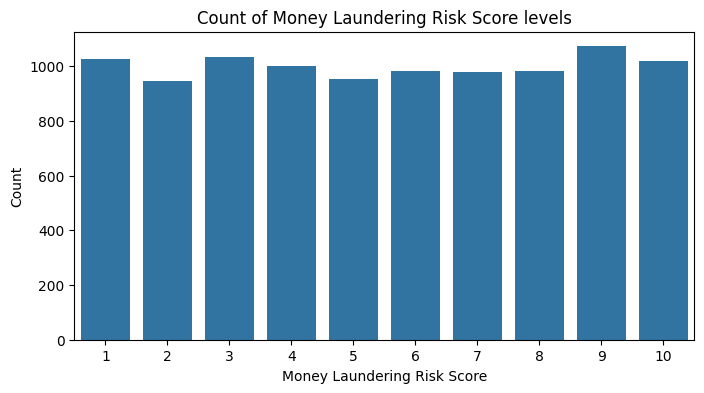

In [10]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df[target_col], order=sorted(df[target_col].unique()))
plt.title("Count of Money Laundering Risk Score levels")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

Количество объектов с разными уровнями риска примерно равны

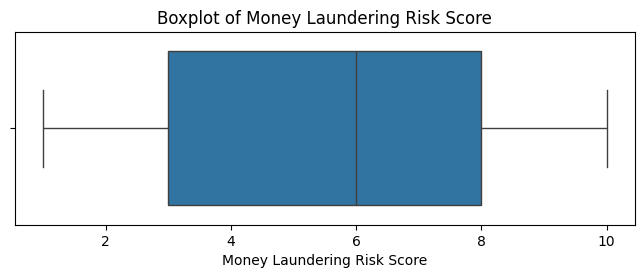

In [7]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df[target_col])
plt.title("Boxplot of Money Laundering Risk Score")
plt.xlabel(target_col)
plt.show()

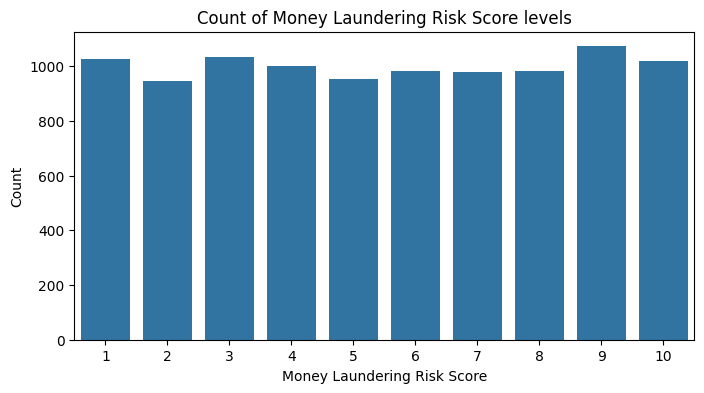

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df[target_col], order=sorted(df[target_col].unique()))
plt.title("Count of Money Laundering Risk Score levels")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['Money Laundering Risk Score',
 'Shell Companies Involved',
 'transaction_year',
 'transaction_month',
 'transaction_dayofweek',
 'transaction_hour',
 'is_illegal',
 'is_reported',
 'has_tax_haven',
 'log_amount',
 'Amount (USD)']

In [13]:
numeric_cols = [col for col in numeric_cols if col != target_col]

In [15]:
categorical_cols = [
    "Industry",
    "Transaction Type",
    "Country",
    "Destination Country",
    "Tax Haven Country",
    "Financial Institution_grouped",
]

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


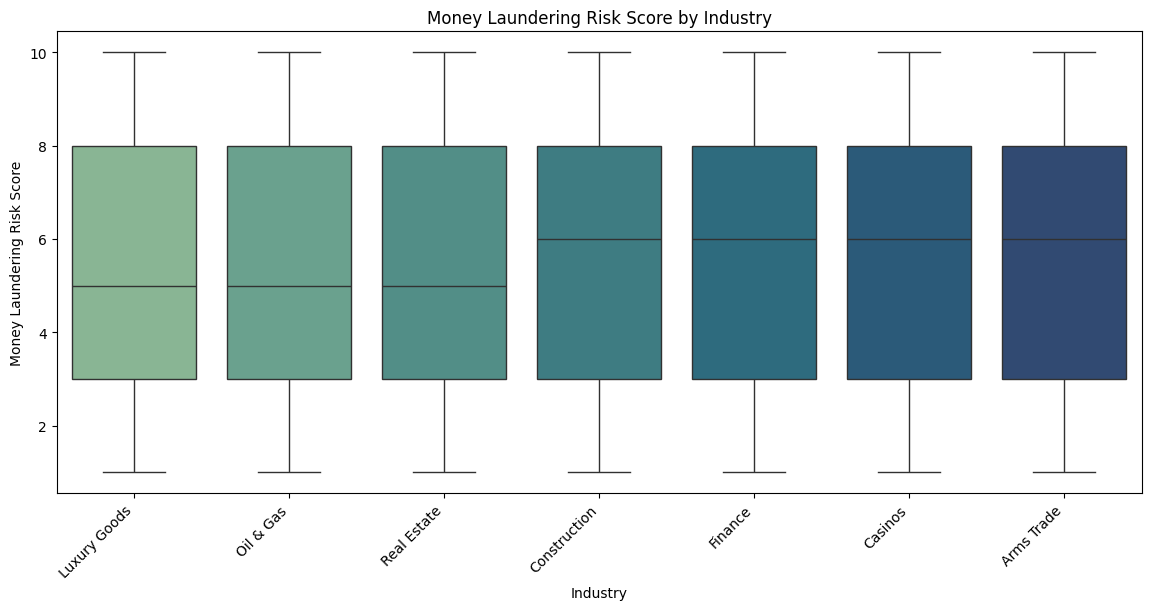

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


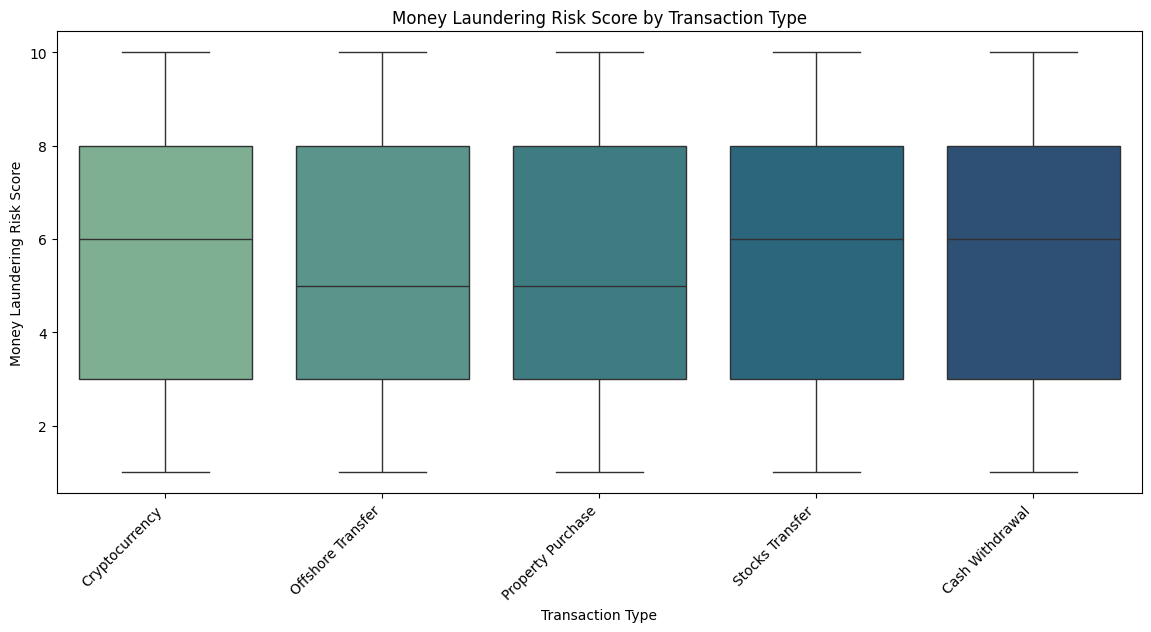

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


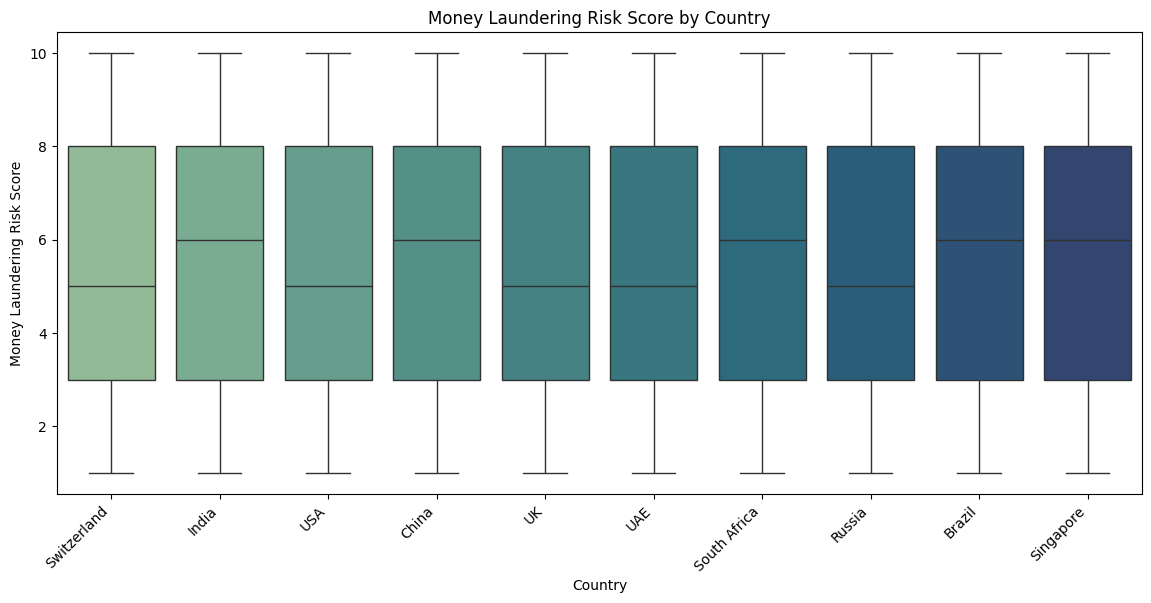

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


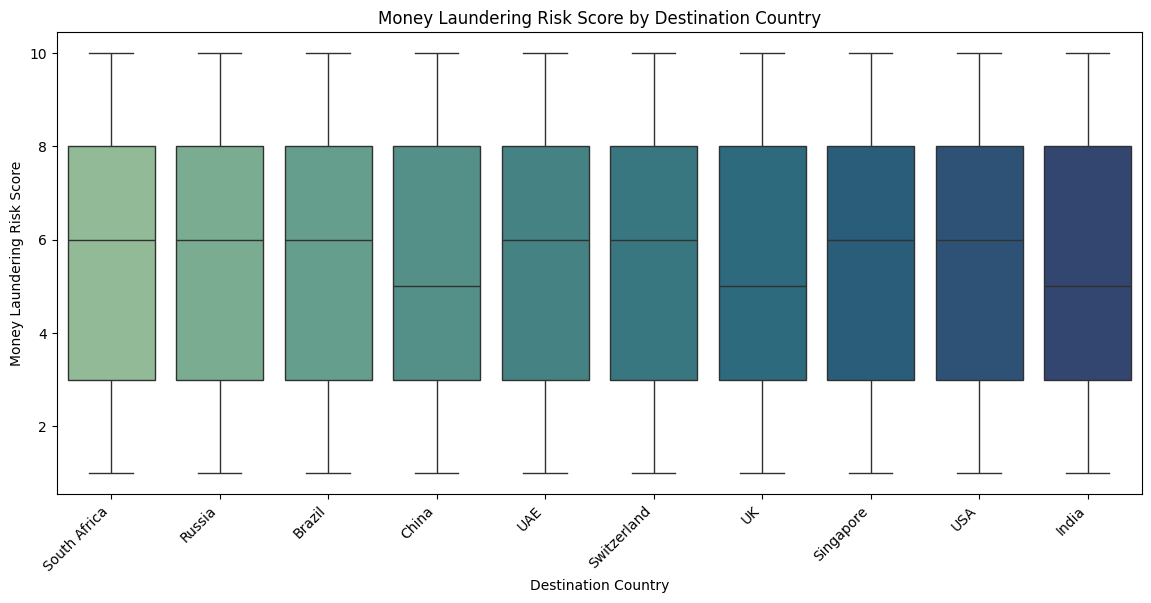

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


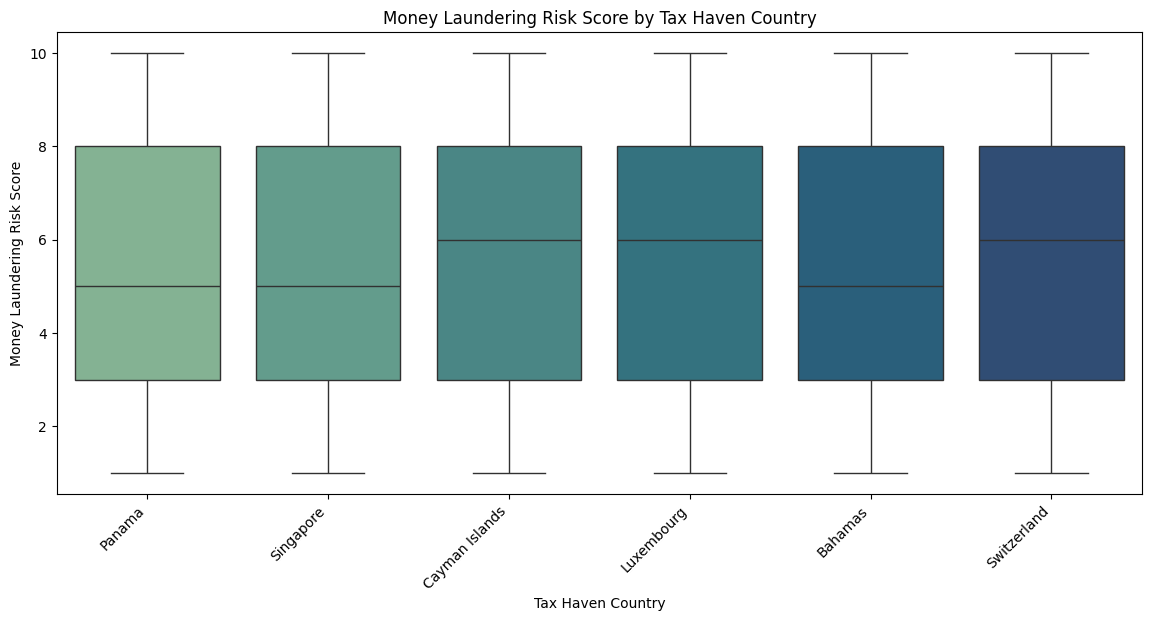

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\3052177111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target_col, palette="crest")


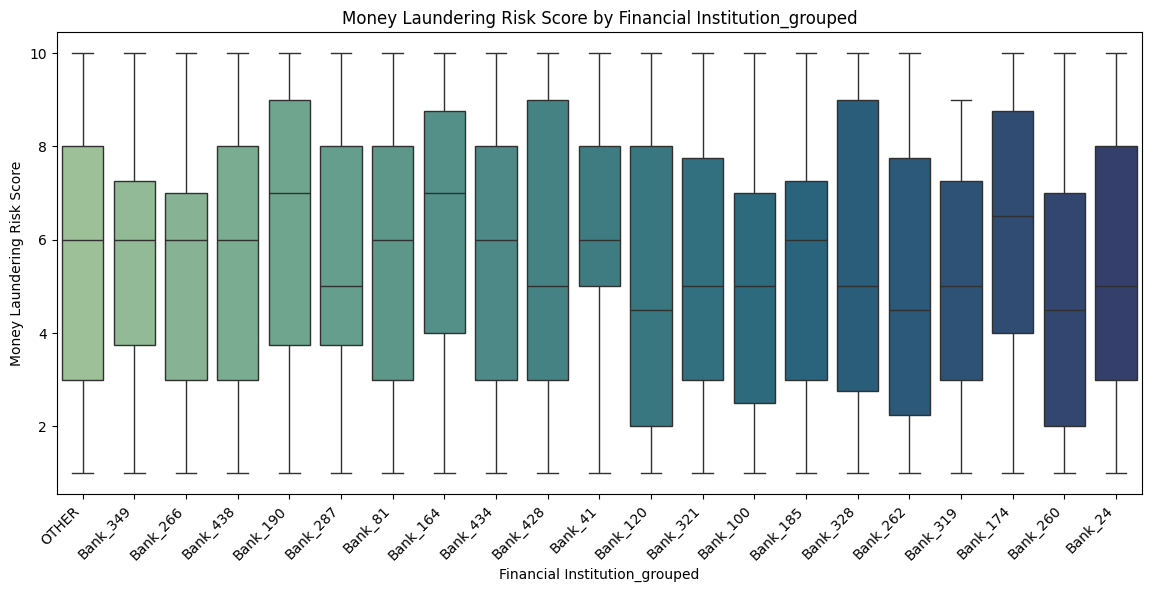

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x=col, y=target_col, palette="crest")
    plt.title(f"{target_col} by {col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.xticks(rotation=45, ha="right")
    plt.show()

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\1713565994.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bank_risk_mean.index, y=bank_risk_mean.values, palette="crest")


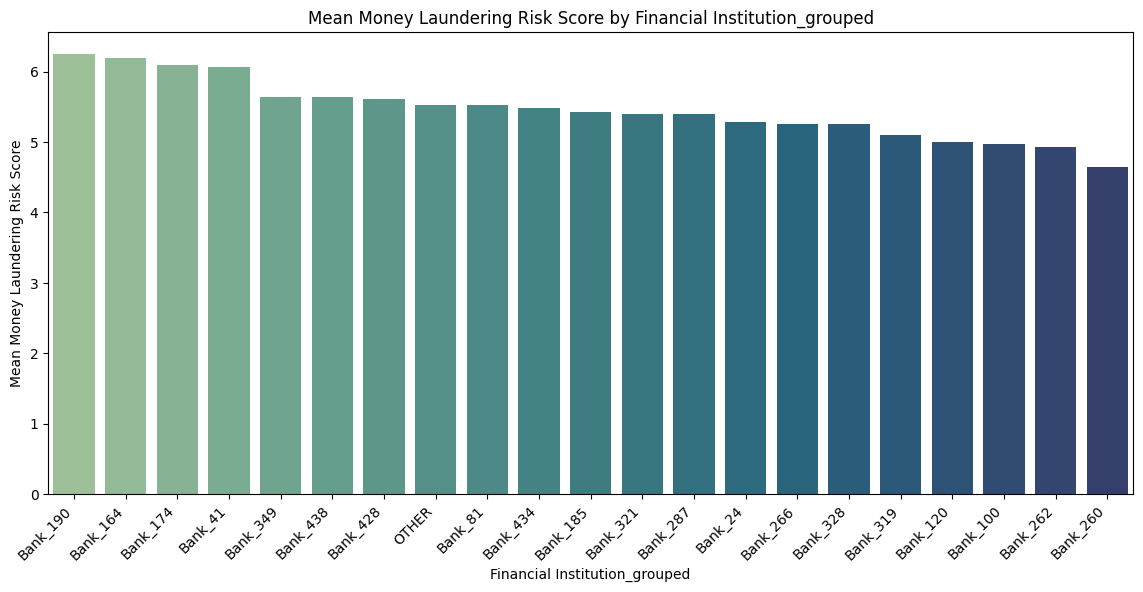

In [17]:
bank_risk_mean = (
    df.groupby("Financial Institution_grouped")[target_col]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=bank_risk_mean.index, y=bank_risk_mean.values, palette="crest")
plt.title(f"Mean {target_col} by Financial Institution_grouped")
plt.xlabel("Financial Institution_grouped")
plt.ylabel(f"Mean {target_col}")
plt.xticks(rotation=45, ha="right")
plt.show()

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\1304665827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_risk_mean.index, y=industry_risk_mean.values, palette="viridis")


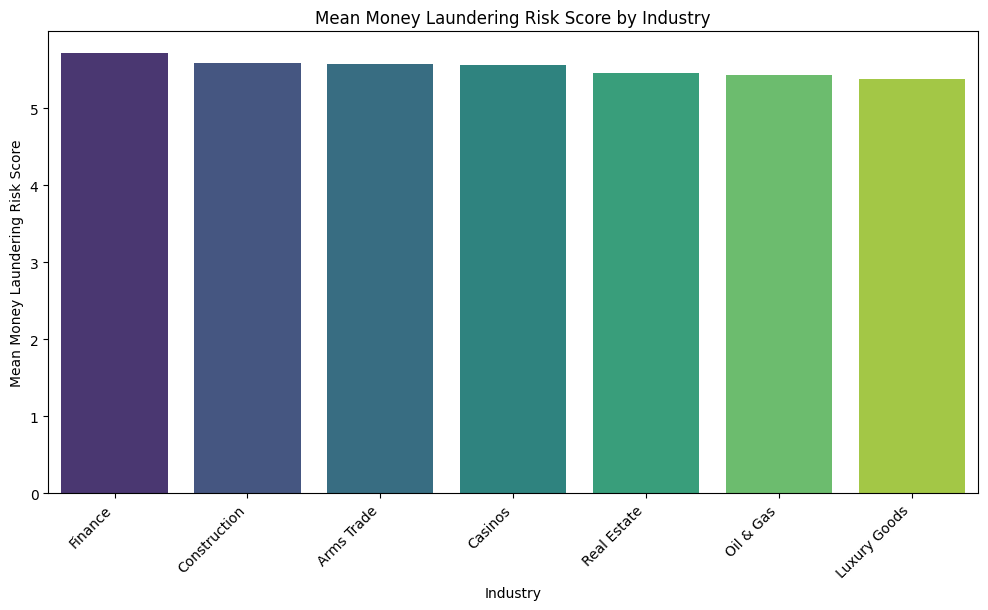

In [18]:
industry_risk_mean = (
    df.groupby("Industry")[target_col]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=industry_risk_mean.index, y=industry_risk_mean.values, palette="viridis")
plt.title(f"Mean {target_col} by Industry")
plt.xlabel("Industry")
plt.ylabel(f"Mean {target_col}")
plt.xticks(rotation=45, ha="right")
plt.show()

C:\Users\Petricia\AppData\Local\Temp\ipykernel_9244\819931561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


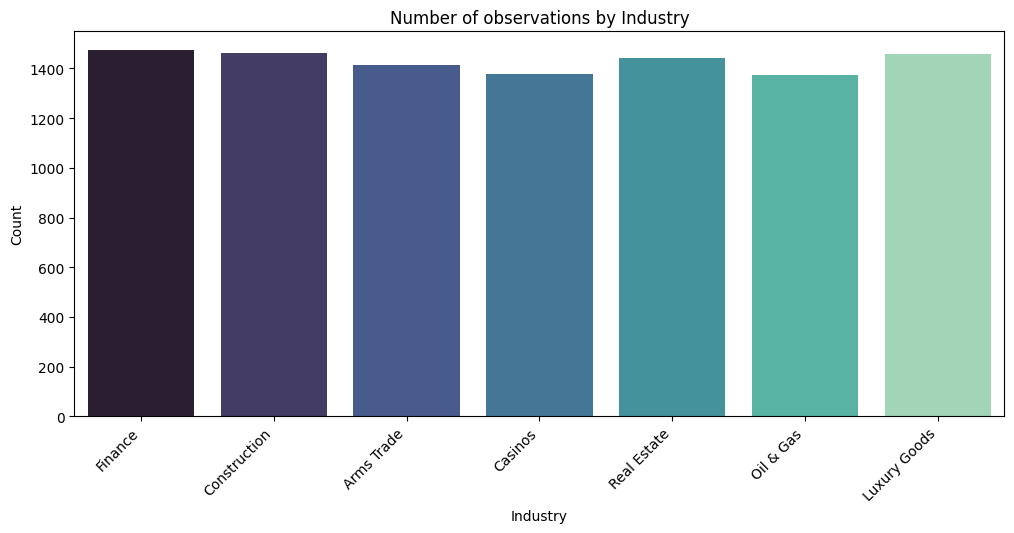

In [21]:
industry_stats = (
    df.groupby("Industry")[target_col]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=industry_stats.reset_index(),
    x="Industry",
    y="count",
    palette="mako"
)
plt.title("Number of observations by Industry")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [23]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.head()

,Money Laundering Risk Score,Shell Companies Involved,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Amount (USD)
0,10,3,2013,7,5,2,1,1,1,13.623577,8.253611e+05
1,10,9,2013,9,3,16,1,0,1,13.222104,5.524413e+05
2,5,1,2013,9,2,10,0,1,1,14.945248,3.094842e+06
3,3,0,2014,1,6,3,1,0,1,14.746832,2.537859e+06
4,1,3,2013,6,2,23,1,0,1,14.920456,3.019059e+06


In [24]:
corr_matrix = numeric_df.corr()
corr_matrix

,Money Laundering Risk Score,Shell Companies Involved,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Amount (USD)
Money Laundering Risk Score,1.000000,-0.019262,-0.010039,-0.010028,-0.004549,-0.004461,0.002059,0.003502,NaN,0.014191,0.016529
Shell Companies Involved,-0.019262,1.000000,0.004209,-0.019785,-0.013645,-0.004395,0.006620,0.020544,NaN,-0.012889,-0.017905
transaction_year,-0.010039,0.004209,1.000000,-0.463295,-0.000161,-0.002458,-0.010019,0.004077,NaN,0.000453,0.001613
transaction_month,-0.010028,-0.019785,-0.463295,1.000000,-0.000304,0.000987,0.009534,-0.008236,NaN,0.003076,0.001579
transaction_dayofweek,-0.004549,-0.013645,-0.000161,-0.000304,1.000000,-0.000466,0.002882,0.003284,NaN,-0.005859,-0.006675
transaction_hour,-0.004461,-0.004395,-0.002458,0.000987,-0.000466,1.000000,-0.032200,0.008276,NaN,0.009960,0.012287
is_illegal,0.002059,0.006620,-0.010019,0.009534,0.002882,-0.032200,1.000000,-0.003226,NaN,-0.005345,-0.011386
is_reported,0.003502,0.020544,0.004077,-0.008236,0.003284,0.008276,-0.003226,1.000000,NaN,0.007445,0.005214
has_tax_haven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_amount,0.014191,-0.012889,0.000453,0.003076,-0.005859,0.009960,-0.005345,0.007445,NaN,1.000000,0.883603


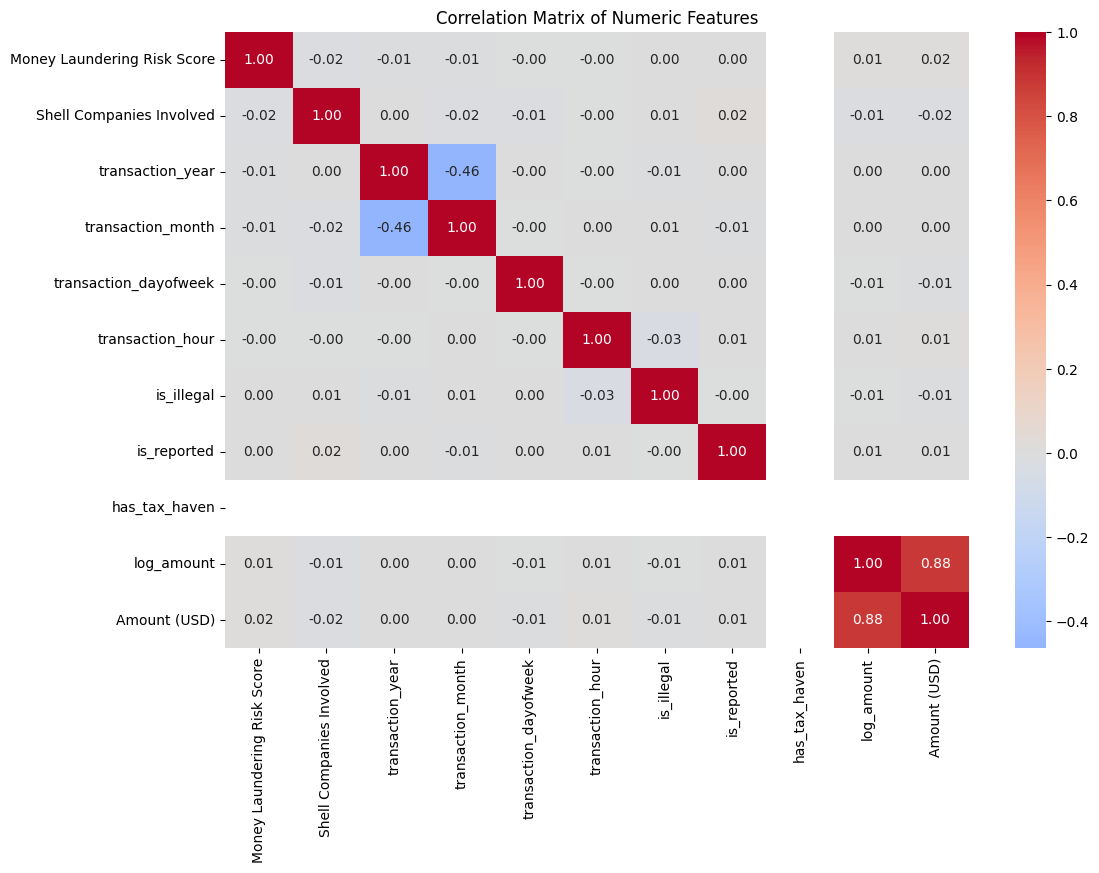

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [26]:
target_corr = corr_matrix[target_col].sort_values(key=lambda x: x.abs(), ascending=False)
target_corr

Money Laundering Risk Score    1.000000
Shell Companies Involved      -0.019262
Amount (USD)                   0.016529
log_amount                     0.014191
transaction_year              -0.010039
transaction_month             -0.010028
transaction_dayofweek         -0.004549
transaction_hour              -0.004461
is_reported                    0.003502
is_illegal                     0.002059
has_tax_haven                       NaN
Name: Money Laundering Risk Score, dtype: float64

По числовым признакам не выявлено значимой линейной связи с таргетом `Money Laundering Risk Score`. Все коэффициенты корреляции по модулю оказались крайне малы (менее 0.03), что указывает на отсутствие выраженной линейной зависимости между уровнем риска и доступными числовыми переменными.

В целом это подтверждает гипотезу о том, что основная информация для нового таргета, скорее всего, содержится не в числовых, а в категориальных признаках.


### Метрики качества

Так как таргет `Money Laundering Risk Score` принимает дискретные значения от 1 до 10 и имеет упорядоченную природу, задача рассматривается как многоклассовая классификация с ordinal-структурой классов.

Для оценки качества моделей используются:

- **Accuracy** — доля точных попаданий в уровень риска.
- **Weighted F1-score** — баланс precision/recall по всем уровням риска с учётом несбалансированности классов.
- **MAE по уровням риска** — средняя абсолютная ошибка \(|y_{\text{true}} - y_{\text{pred}}|\), показывающая, на сколько уровней в среднем промахивается модель.
- (опционально) **RMSE по уровням** — подчёркивает крупные ошибки, когда модель сильно занижает или завышает уровень риска.

Основными решающими метриками считаем **weighted F1** и **MAE по уровням**, а accuracy и RMSE используем как вспомогательные показатели.